# Regressão Logística

## 1. Fundamentos da Regressão Logística

A classificação binária é o processo de classificar um conjunto de dados em duas categorias distintas e exclusivas. O objetivo é criar um modelo que, ao receber uma nova informação, consiga prever a qual desses dois grupos ela pertence. Geralmente, representamos essas classes matematicamente como 0 (negativo/ausência) e 1 (positivo/presença).

Usualmente, no processo de classificação, a saída do modelo de aprendizado de máquina retorna uma probabilidade de um novo dado de entrada pertencer a uma determinada classe. Essa probabilidade, que varia no intervalo entre 0 e 1, indica o nível de confiança do modelo em sua previsão. Para que o sistema tome uma decisão final (classifique o dado como 0 ou 1), aplica-se um limiar de decisão (*threshold*), que por padrão costuma ser 0,5.

Por exemplo, supondo um modelo de classificação de spam, em que a saída $y = 1$ refere-se à uma mensagem com spam e $y = 0$ refere-se a uma mensagem sem spam. O modelo de classificação binária retorna uma probabilidade condicional $P(y=1|x)$, que representa a probabilidade de a mensagem ser um spam, dado um conjunto de características $x$ (como palavras-chave ou o remetente). Após isso, o algoritmo pode utilizar uma decisão por limiar:

* Se a probabilidade for $\ge 0,5$, o e-mail é classificado como Classe 1 (Spam).
* Se a probabilidade for $< 0,5$, o e-mail é classificado como Classe 0 (Desejado).

A primeira ideia para solucionar o problema de classificação binária seria utilizar a regressão linear. A regressão linear busca ajustar uma reta aos dados. No entanto, a regressão linear pode prever valores como -1,5 ou 2,0. Em classificação, buscamos uma probabilidade $P(y=1|x)$, que deve estar estritamente entre $0$ e $1$.

Para resolver isso, "esmagamos" a saída da equação linear usando a função logística (sigmoide). A função logística garante que a saída do modelo fique limitada sempre à valores entre 0 e 1. A função logística é definida como:

$$
h_\theta(z) = \frac{1}{1 + e^{-z}}
$$

A característica da função logística é apresentada abaixo:

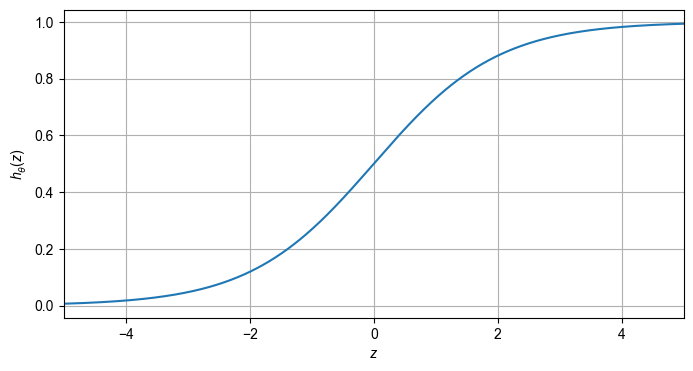

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Muda a fonte dos Plots para Arial
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 4)

z = np.linspace(-5,5,1000)
f = 1/(1 + np.exp(-z))

plt.plot(z,f)
plt.xlim(-5,5)
plt.ylabel('$h_{\\theta}(z)$')
plt.xlabel('$z$')
plt.grid()
plt.show()

Verificar que mesmo para valores muito altos ou muito baixos de $z$, a saída $f(z)$ sempre está limitada ao intervalo de $[0,1]$ e portanto, pode ser utilizada para realizar a previsão de uma probabilidade. Assim sendo, podemos aplicar na entrada da função logística, um modelo descrito por uma relação linear de variáveis, ou seja:

$$
z = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_p x_p
$$

logo, a saída do modelo de regressão logística será:

$$
\hat{p} = h_\theta(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_p x_p) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_p x_p)}}
$$

De forma equivalente, podemos representar o nosso modelo de forma vetorial,

$$
\hat{p} = h_\theta\left(\Phi^T\mathbf{x}\right) = \frac{1}{1 + e^{-\Phi^T\mathbf{x}} }
$$

em que:
* $\mathbf{x} = [ 1 \quad x_1 \quad x_2 \quad \cdots \quad x_p ]^T$ é o vetor de entrada (ou vetor de características), onde o valor $1$ é adicionado para permitir o produto escalar com o termo de intercepto (bias).
* $\Phi = [  \theta_0 \quad \theta_1 \quad \theta_2 \quad \cdots \quad \theta_p ]^T$ é o vetor de parâmetros (ou pesos) do modelo.

Dessa forma, o produto escalar $\mathbf{x}^T\Phi$ resulta exatamente na combinação linear $z = \theta_0 + \theta_1 x_1 + \dots + \theta_p x_p$, que é então processada pela função sigmoide para gerar a probabilidade $\hat{p}$.

## 2. Ajuste dos Parâmetros do Modelo

Diferente da Regressão Linear, que utiliza o erro quadrático médio, a regressão logística utiliza uma função de custo chamada Log Loss (ou entropia cruzada binária).

A ideia fundamental é punir o modelo com base na distância entre a probabilidade prevista ($\hat{p}$) e o rótulo real ($y$). O custo para um único exemplo é definido em duas partes:
* Se o valor real é $y=1$, então o custo é $-\log(\hat{p})$.
  - Se o modelo prevê $\hat{p} = 1$, o custo é $0$.
  - À medida que $\hat{p}$ se aproxima de $0$, o custo cresce infinitamente.
* Se o valor real é $y=0$, então o custo é $-\log(1 - \hat{p})$.
  - Se o modelo prevê $\hat{p} = 0$, o custo é $0$.
  - À medida que $\hat{p}$ se aproxima de $1$, o custo cresce infinitamente.

Para treinar o modelo, somamos o custo de todos os $N$ exemplos de treinamento em uma única fórmula compacta:

$$
J(\theta) = -\frac{1}{N} \sum_{i=0}^{N-1} y^{(i)} \log\left(\hat{p}^{(i)}\right) + \left(1 - y^{(i)}\right) \log\left(1 - \hat{p}^{(i)}\right)
$$

onde:
* $N$: Número total de amostras.
* $y^{(i)}$: Rótulo real do exemplo $i$ ($0$ ou $1$).
* $\hat{p}^{(i)}$: Probabilidade prevista pelo modelo para o exemplo $i$.

Como $\hat{p}^{(i)} = h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right)$, então:

$$
J(\theta) = -\frac{1}{N} \sum_{i=0}^{N-1} y^{(i)} \log\left[h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right)\right] + \left(1 - y^{(i)}\right) \log\left[1 - h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right)\right]
$$

Veja que se $y^{(i)} = 1$, então $1 - y^{(i)}$, e o termo $\log\left(1 - \hat{p}^{(i)}\right)$ some da expressão, selecionando o valor correto para a punição para cada um dos casos.

O objetivo do treinamento é encontrar os parâmetros $\theta$ (pesos) que minimizam $J(\theta)$. Fazemos isso calculando a derivada da função de custo em relação a cada peso. Tomando-se as derivadas parciais em termos dos parâmetros, temos que:

$$
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{N} \sum_{i=0}^{N-1} \left[h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right) - y^{(i)}\right] x_j^{(i)}
$$

### 2.1. Algoritmo do Gradiente Descendente

A solução analítica para os parâmetros do modelo da regressão linear é um processo tedioso e muito complexo. Nessas situações, podemos utilizar o algoritmo do gradiente descendente para determinar os valores de coeficientes que minimizam a função de erro.

O gradiente descendente é um algoritmo de minimação capaz de encontrar soluções ótimas para uma ampla gama de problemas. A ideia geral do gradiente descendente é ajustar os parâmetros iterativamente para minimizar uma função de custo.

Imagine que você está no topo de uma montanha coberta por uma neblina tão densa que você não consegue enxergar a base. Seu objetivo é chegar ao ponto mais baixo (o mínimo da função de custo), onde o erro do seu modelo é o menor possível.

Como você não vê o caminho todo, você usa a seguinte estratégia:

1. Sentir a inclinação;
2. O tamanho do passo (*Learning Rate*): Você precisa decidir o quão grande será o seu passo ($\alpha$).
3. Repetição até a planície: Você repete o processo. Você para quando percebe que, para qualquer lado que você tente ir, o chão não desce mais. Isso significa que você atingiu a base.

Graficamente, o processo de algoritmo gradiente descendente pode ser visto na Figura abaixo:

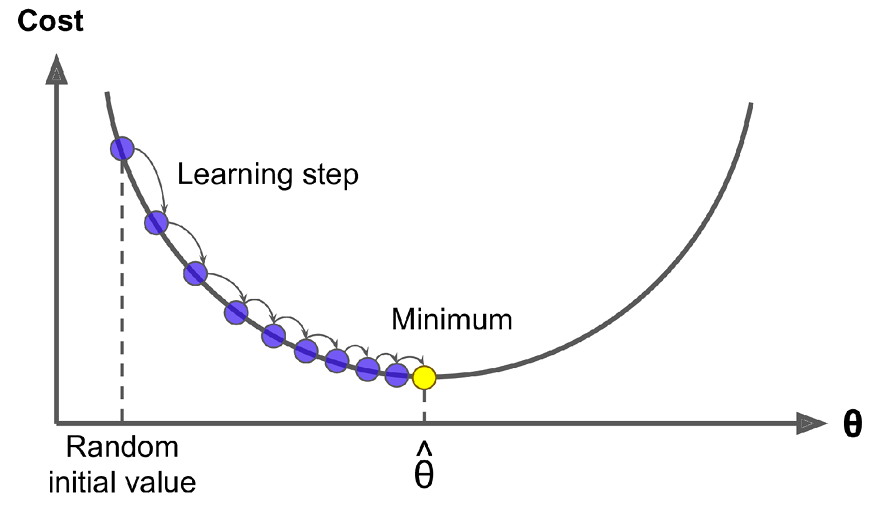

Um parâmetro importante no gradiente descendente é o tamanho dos passos, determinado pelo hiperparâmetro da taxa de aprendizagem. Se a taxa de aprendizagem for muito pequena, o algoritmo precisará passar por muitas iterações para convergir, o que levará muito tempo.

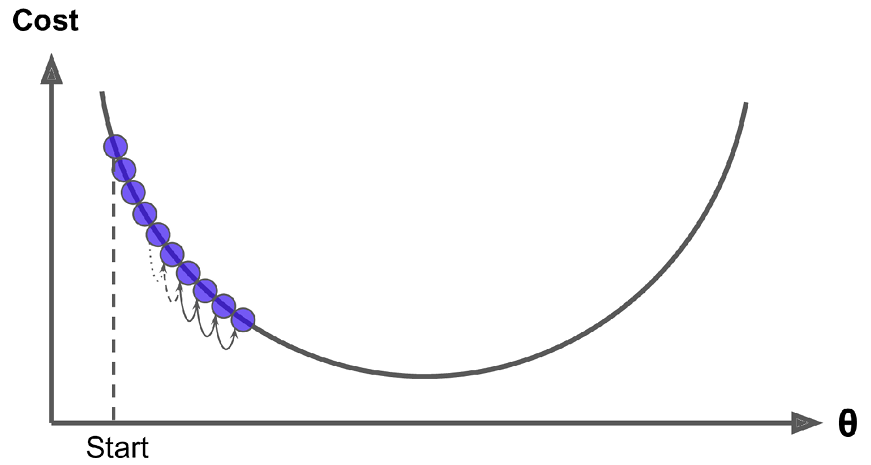

Por outro lado, se a taxa de aprendizado for muito alta, você pode pular o vale e acabar do outro lado, possivelmente até mais alto do que estava antes. Isso pode fazer com que o algoritmo divirja, com valores cada vez maiores, falhando em encontrar uma boa solução.

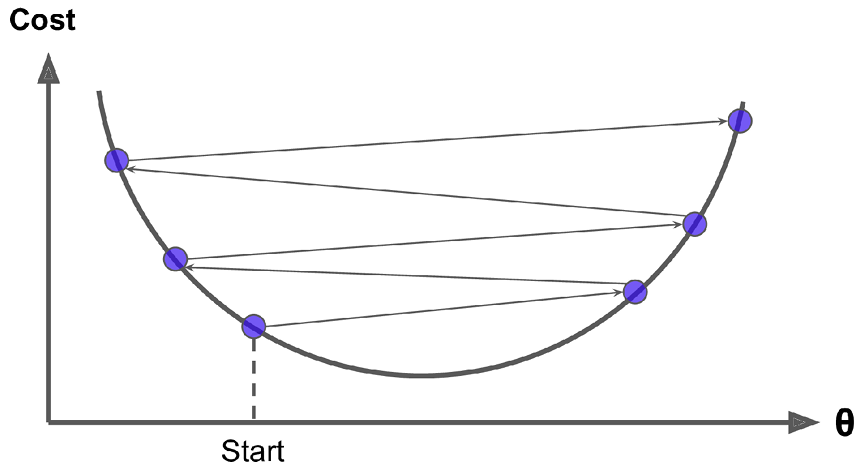

Por fim, a função de custo pode conter vários mínimos locais. Nessas situações, o algoritmo gradiente descendente pode ficar "preso" em algum desses mínimos locais, prejudicando o desempenho de treinamento.

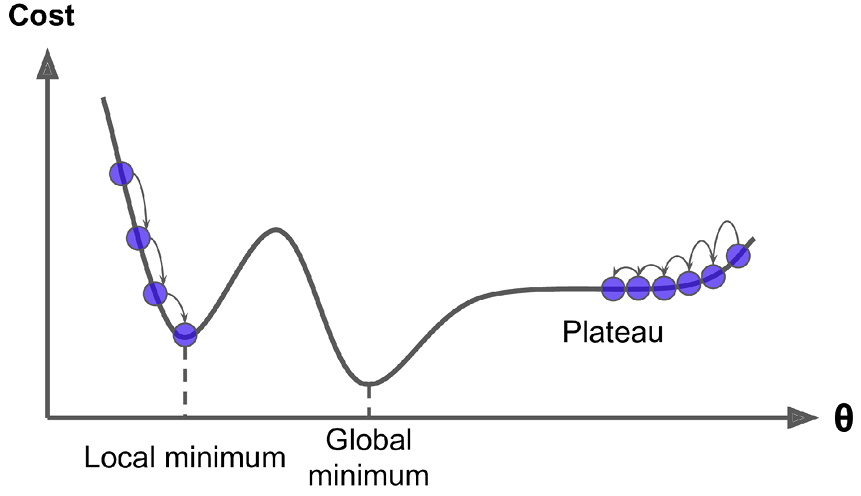

#### Regra de Ajuste para a Regressão Logística

Para cada parâmetro $\theta_j$ do modelo, a regra de atualização é:

$$
\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)
$$

Onde:
* $\theta_j$: O peso que queremos ajustar.
* $\alpha$: taxa de aprendizado (*learning rate*), que controla o tamanho do "passo" em direção ao mínimo.
* $\frac{\partial}{\partial \theta_j} J(\theta)$: O gradiente (derivada), que indica a direção de maior subida. Ao subtrairmos, caminhamos na direção oposta (descida).
  
Para a Regressão Logística, após calcular a derivada da função Log-Loss, a fórmula expandida para a atualização de todos os pesos simultaneamente é:

$$
\theta_j := \theta_j - \alpha \frac{1}{N} \sum_{i=0}^{N-1} \left[ h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right) - y^{(i)} \right] x_j^{(i)}
$$

---

**Exemplo 1:** Suponha uma modelo que indique a probabilidade de alguem passar na disciplina de Sistemas Inteligentes baseada na quantidade de horas estudadas. Vamos treinar um modelo de regressão logística para prever a probabilidade de sucesso supondo uma determinada quantidade de horas.

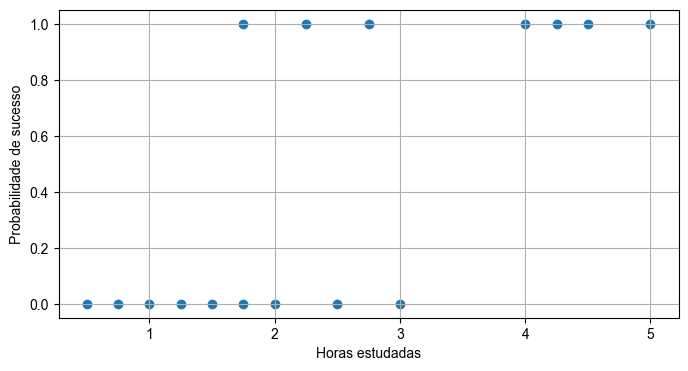

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Gerando dados sintéticos: Horas de estudo vs Passar na prova (0 ou 1)
X_raw = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 4.0, 4.25, 4.5, 5.0])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1])

plt.scatter(X_raw,y)
plt.xlabel('Horas estudadas')
plt.ylabel('Probabilidade de sucesso')
plt.grid()
plt.show()

Vamos definir a função logística:

$$
h_\theta(z) = \frac{1}{1 + e^{-z}}
$$

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Definindo a função de custo:

$$
J(\theta) = -\frac{1}{N} \sum_{i=0}^{N-1} y^{(i)} \log\left[h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right)\right] + \left(1 - y^{(i)}\right) \log\left[1 - h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right)\right]
$$

In [4]:
def compute_cost(X, y, theta):
    N = len(y)
    z = np.dot(X, theta)
    h = sigmoid(z)
    
    # Evita log(0) adicionando um valor minúsculo (epsilon)
    epsilon = 1e-15
    cost = -(1/N) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

E por fim, vamos definir a função que implementa o gradiente descendente:

$$
\theta_j := \theta_j - \alpha \frac{1}{N} \sum_{i=0}^{N-1} \left[ h_\theta\left(\Phi^T\mathbf{x}^{(i)}\right) - y^{(i)} \right] x_j^{(i)}
$$

In [5]:
def gradient_descent(X, y, theta, alpha, iterations):
    N, p = X.shape
    cost_history = []
    
    for i in range(iterations):
        z = np.dot(X, theta) 
        h = sigmoid(z)
        error = h - y        
        gradient = (1/N) * np.dot(X.T, error)
        #gradient = (1/N) * np.sum(error.T*X)
        
        theta = theta - alpha * gradient
        cost_history.append(compute_cost(X, y, theta))
        
        if i % 100 == 0:
            print(f"Iteração {i}: Custo {cost_history[-1]:.4f}")
            
    return theta, cost_history

Para o algoritmo funcionar, o vetor $\mathbf{x}$ deve possuir uma coluna apenas com valores `1`:

In [6]:
X = np.column_stack((np.ones(X_raw.shape[0]), X_raw))
X

array([[1.  , 0.5 ],
       [1.  , 0.75],
       [1.  , 1.  ],
       [1.  , 1.25],
       [1.  , 1.5 ],
       [1.  , 1.75],
       [1.  , 1.75],
       [1.  , 2.  ],
       [1.  , 2.25],
       [1.  , 2.5 ],
       [1.  , 2.75],
       [1.  , 3.  ],
       [1.  , 4.  ],
       [1.  , 4.25],
       [1.  , 4.5 ],
       [1.  , 5.  ]])

Utilizando a função de treinamento:

In [7]:
alpha = 0.1
iterations = 1000

theta = np.zeros(X.shape[1])                    # Inicializacao com Zeros
#theta = np.random.randn(X.shape[1])            # Inicializacao aleatória
final_theta, history = gradient_descent(X, y, theta, alpha, iterations)
final_theta

Iteração 0: Custo 0.6834
Iteração 100: Custo 0.5145
Iteração 200: Custo 0.4520
Iteração 300: Custo 0.4225
Iteração 400: Custo 0.4066
Iteração 500: Custo 0.3973
Iteração 600: Custo 0.3914
Iteração 700: Custo 0.3876
Iteração 800: Custo 0.3850
Iteração 900: Custo 0.3831


array([-3.84866733,  1.51797539])

Desta forma, a equação que prevê a probabilidade de um estudante passar na prova dado uma quantidade $x$ de horas estudadas é:

$$
\hat{p} = \frac{1}{1 + e^{-(-3,85 + 1,52x)}}
$$

Podemos plotar também a curva de aprendizado, que relaciona a função de custo em função do número de iterações:

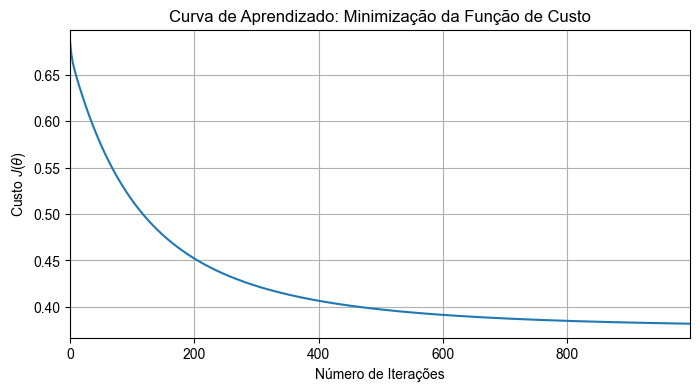

In [8]:
plt.plot(history)
plt.title('Curva de Aprendizado: Minimização da Função de Custo')
plt.xlabel('Número de Iterações')
plt.ylabel('Custo $J(\\theta)$')
plt.xlim([0, iterations-1])
plt.grid()
plt.show()

Assim sendo, se quisermos saber a probabilidade de sucesso de um estudante que estudou por 4,5 h, poderemos fazer:

In [9]:
def p_est(x):
    return sigmoid(final_theta[0] + final_theta[1]*x)

x = 4.5
print(f"Probabilidade de sucesso = {p_est(x)}")

Probabilidade de sucesso = 0.9517644806381729


Da mesma forma, a probabilidade de sucesso de um estudante que estou somente 1 h pode ser calculada como:

In [10]:
x = 1
print(f"Probabilidade de sucesso = {p_est(x)}")

Probabilidade de sucesso = 0.0886127662554067


Por fim, vamos apresentar o gráfico que indica a curva de probabilidade treinada em função dos dados do conjunto de treinamento:

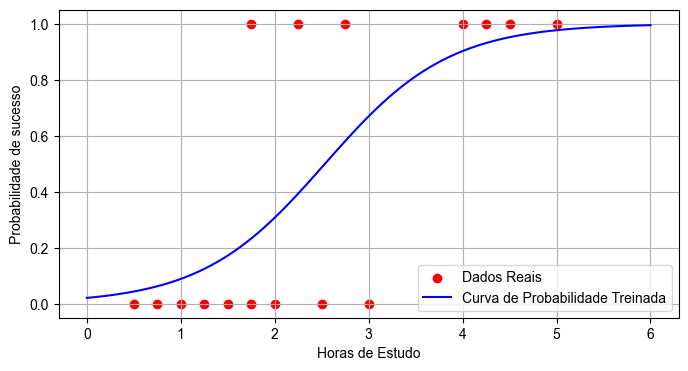

In [11]:
X_plot = np.linspace(0, 6, 100)
probabilidades = p_est(X_plot)

plt.scatter(X_raw, y, color='red', label='Dados Reais')
plt.plot(X_plot, probabilidades, color='blue', label='Curva de Probabilidade Treinada')
plt.xlabel('Horas de Estudo')
plt.ylabel('Probabilidade de sucesso')
plt.legend()
plt.grid()
plt.show()

### 2.2. Ajuste dos Parâmetros através da `sklearn`

Assim como na regressão linear, a biblioteca `sklearn` também apresenta os algoritmos para o ajuste dos parâmetros da regressão logística. Neste caso, utilizaremos o modelo `LogisticRegression` e utilizaremos o método `fit()` para o ajuste dos parâmetros do modelo.

<hr>

**Exemplo 2:** Realize o ajuste dos parâmetros do modelo de regressão logística do Exemplo 1 utilizando a `sklearn`.

Vamos utilizar o mesmo conjunto de dados. É importante dizer que não é necessário adicionar a coluna de `1` para treinar o modelo, pois o `sklearn` já faz isso internamente:

In [12]:
from sklearn.linear_model import LogisticRegression

# Gerando dados sintéticos: Horas de estudo vs Passar na prova (0 ou 1)
X_raw = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 4.0, 4.25, 4.5, 5.0])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1])
X_raw.reshape(-1, 1)

array([[0.5 ],
       [0.75],
       [1.  ],
       [1.25],
       [1.5 ],
       [1.75],
       [1.75],
       [2.  ],
       [2.25],
       [2.5 ],
       [2.75],
       [3.  ],
       [4.  ],
       [4.25],
       [4.5 ],
       [5.  ]])

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_raw.reshape(-1, 1), y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Os valores de $\theta_0$ e $\theta_1$ podem ser obtidos como:

In [14]:
t0 = model.intercept_[0]
t1 = model.coef_[0][0]

print(f"theta0 = {t0}")
print(f"theta1 = {t1}")

theta0 = -3.1385517345337437
theta1 = 1.184598083824479


Verificar que, embora os valores sejam próximos ao obtidos no Exemplo 1, os valores de $\theta_0$ e $\theta_1$ são diferentes. Isso ocorre pois a implementação do gradiente descendente da `sklearn` utiliza métodos avançados para o ajuste do passo de aprendizagem. Desta forma, a equação que prevê a probabilidade de um estudante passar na prova dado uma quantidade $x$ de horas estudadas é:

$$
\hat{p} = \frac{1}{1 + e^{-(-3,14 + 1,18x)}}
$$

Por fim, vamos apresentar o gráfico que indica a curva de probabilidade treinada em função dos dados do conjunto de treinamento:

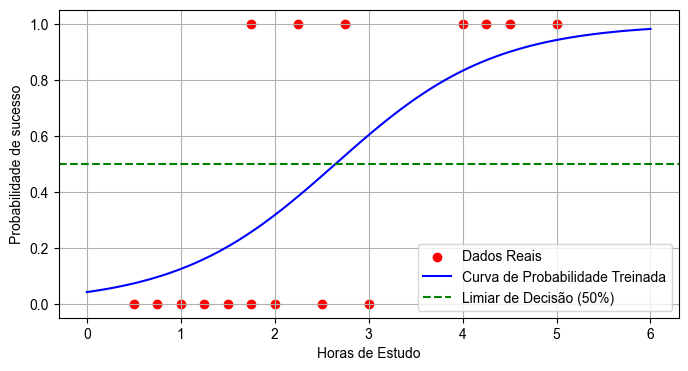

In [15]:
X_plot = np.linspace(0, 6, 100)

X_plot_mat = np.column_stack((np.ones(X_plot.shape[0]), X_plot))
probabilidades = sigmoid(np.dot(X_plot_mat, [t0, t1]))

plt.scatter(X_raw, y, color='red', label='Dados Reais')
plt.plot(X_plot, probabilidades, color='blue', label='Curva de Probabilidade Treinada')
plt.axhline(0.5, color='green', linestyle='--', label='Limiar de Decisão (50%)')
plt.xlabel('Horas de Estudo')
plt.ylabel('Probabilidade de sucesso')
plt.legend()
plt.grid()
plt.show()

Assim sendo, se quisermos saber a probabilidade de sucesso de um estudante que estudou por 4,5 h, poderemos fazer:

In [16]:
def p_est(x):
    return sigmoid(t0 + t1*x)

x = 4.5
print(f"Probabilidade de sucesso = {p_est(x)}")

Probabilidade de sucesso = 0.8995414241373972


Da mesma forma, a probabilidade de sucesso de um estudante que estou somente 1 h pode ser calculada como:

In [17]:
x = 1
print(f"Probabilidade de sucesso = {p_est(x)}")

Probabilidade de sucesso = 0.12412289236677579


---

## 3. Avaliação em Classificação Binária

No processo de classificação binária, devemos treinar um modelo para separar um conjunto de dados em duas categorias exclusivas, geralmente representadas como 0 ou 1, Verdadeiro ou Falso, ou Positivo ou Negativo.

O modelo recebe características de entrada ($x$) e tenta prever a qual classe ($y$) aquele dado pertence. Para isso, ele geralmente calcula uma probabilidade. Se a probabilidade for maior que um determinado limiar (comumente 0.5), o dado é classificado como Positivo; caso contrário, Negativo.

### 3.1. Matriz de Confusão

A Matriz de Confusão é uma ferramenta de visualização de desempenho para algoritmos de classificação (especialmente binária). Em um cenário de classificação binária (onde temos as classes Positivo e Negativo), a matriz é uma tabela $2 \times 2$:

<table style="width:60%; text-align:center; border: 2px solid #808080; border-collapse: collapse">
  <tr>
    <th rowspan="2">Real</th>
    <th colspan="2">Predito</th>
  </tr>
  <tr>
    <th>Positivo</th>
    <th>Negativo</th>
  </tr>
  <tr>
    <td><b>Positivo</b></td>
    <td style="background-color: #e6ffed; color: black">Verdadeiro Positivo (VP)</td>
    <td style="background-color: #ffeef0; color: black">Falso Negativo (FN)</td>
  </tr>
  <tr>
    <td><b>Negativo</b></td>
    <td style="background-color: #ffeef0; color: black">Falso Positivo (FP)</td>
    <td style="background-color: #e6ffed; color: black">Verdadeiro Negativo (VN)</td>
  </tr>
</table>

Neste contexto, define-se:

* Verdadeiro Positivo (VP): O valor real era positivo e o modelo previu positivo. (Acerto)
* Verdadeiro Negativo (VN): O valor real era negativo e o modelo previu negativo. (Acerto)
* Falso Positivo (FP): O valor real era negativo, mas o modelo previu positivo. (Erro Tipo I - "Alarme Falso")
* Falso Negativo (FN): O valor real era positivo, mas o modelo previu negativo. (Erro Tipo II - "Omissão")

#### Acurácia

Indica a performance geral do modelo, ou seja, quanto ele acertou do total.

$$
\textrm{Acurácia} = \frac{VP + VN}{VP + VN + FP + FN}
$$

#### Precisão

Mede a proporção de verdadeiros positivos entre todas as predições positivas. Responde à pergunta: "De todos que o modelo classificou como Positivo, quantos eram realmente Positivos?". Penaliza os falsos positivos. Use quando um alarme falso é caro — por exemplo, filtrar e-mails legítimos como spam.

$$
\textrm{Precisão} = \frac{VP}{VP + FP}
$$

#### Recall

Mede a proporção de verdadeiros positivos e dados realmente positivos. Responde à pergunta: "De todos que eram realmente Positivos, quantos o modelo conseguiu detectar?". Penaliza os falsos negativos. Use quando deixar escapar um positivo é perigoso — por exemplo, não detectar um tumor maligno.

$$
\textrm{Recall} = \frac{VP}{VP + FN}
$$

#### F-1 Score

É a média harmônica entre Precisão e Recall. Ela é muito útil quando você precisa de um equilíbrio entre as duas métricas e tem classes desbalanceadas.

$$
F_1 = 2 \frac{\textrm{Precisão} \cdot \textrm{Recall}}{\textrm{Precisão} + \textrm{Recall}}
$$

### 3.2. Curva ROC

A curva ROC (do inglês *Receiver Operating Characteristic*, ou Característica de Operação do Receptor) é uma ferramenta gráfica essencial para avaliar o desempenho de um modelo de classificação binária.

A curva é plotada em um plano bidimensional definido por dois índices fundamentais:
* Eixo Y: Recall.
* Eixo X: Representa a proporção de casos negativos que foram incorretamente classificados como positivos.

$$
TFP = \frac{FP}{FP + VN}
$$

Em um classificador perfeito, a curva passaria pelo canto superior esquerdo (coordenada 0,1), onde a sensibilidade é 100% e a taxa de falsos positivos é 0%.

Para resumir a curva ROC em um único valor numérico, utilizamos o AUC (*Area Under the Curve*). Quanto mais próximo de 1,0 for o valor do AUC, melhor é o nosso classificador.

---

**Exemplo 3:** Vamos utilizar uma regressão logística para classificar se um determinado achado em um exame de mama é cancerígeno ou não. As características são calculadas a partir de uma imagem digitalizada de uma amostra obtida por punção aspirativa com agulha fina de uma massa mamária. Elas descrevem as características dos núcleos celulares presentes na imagem.

Vamos importar as bibliotecas necessárias:

In [18]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve, accuracy_score, 
    precision_score, recall_score, f1_score
)

Agora vamos importar o nosso *dataset*:

In [19]:
data = load_breast_cancer()
X, y = data.data, data.target
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


Para uma melhor visualização, vamos transformar nossos dados em um *dataframe*:

In [20]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


A quantidade de amostras do nosso *dataset* e a quantidade e features podem ser obtidas como: 

In [21]:
print(f"Quantidade de amostras = {X.shape[0]}")
print(f"Quantidade de features = {X.shape[1]}")

Quantidade de amostras = 569
Quantidade de features = 30


O nosso conjunto de dados possui apenas duas classes, maligno e benigno, como indicado abaixo:

In [22]:
print(data.target_names)

['malignant' 'benign']


A quantidade de amostras referentes à achados malignos e benignos são:

In [23]:
print(f"Quantidade de amostras malígnas = {np.bincount(y)[0]}")
print(f"Quantidade de amostras benigno = {np.bincount(y)[1]}")

Quantidade de amostras malígnas = 212
Quantidade de amostras benigno = 357


Vamos realizar o nosso treinamento. Inicialmente vamos dividir nosso *dataset* em conjunto de treinamento e conjunto de teste:

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 398 amostras
Teste:  171 amostras


Como estamos tratando de um problema muldimensional, é necessário realizar uma normalização dos dados. Vamos utilizar a padronização em cima do conjunto de treinamento e de teste:

In [25]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)      #Nao é necessario o fit_transform pois a media e a variancia
                                           #ja foram calculados

Agora vamos criar nosso modelo de regressão logística e realizar o treinamento:

In [26]:
model = LogisticRegression(
    max_iter=1000,     # máximo de iterações
)

model.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Finalizado o treinamento, podemos obter os parâmetros do modelo através dos atributos `intercept_` e `coef_` do modelo treinado:

In [27]:
t0 = model.intercept_
tvalues = model.coef_[0]

print(f"θ0 = {t0}")
print(f"θ1, θ2, ..., θ30 = {tvalues}")

θ0 = [0.44421352]
θ1, θ2, ..., θ30 = [-0.36619067 -0.36158121 -0.32048262 -0.41717824 -0.19220365  0.62202349
 -0.74767423 -1.1036456   0.22162459  0.13947621 -1.24418536  0.15440679
 -0.61111145 -0.86862326 -0.17719412  0.60075293 -0.08321267 -0.46939674
  0.50545235  0.69486112 -0.81452982 -1.29113423 -0.5373691  -0.77404741
 -0.49635091  0.11840842 -0.97487392 -0.80805037 -1.20249734 -0.10324298]


Após treinado o modelo, poderemos utilizar-ló para realizar a previsão para novos valores. Neste caso, vamos salvar o vetor de parâmetros $\mathbb{\Phi}$ e utilizar a expressão da regressão logística para determinar a probabilidade do achado ser benigno. Relembrando que a probabilidade pode ser calculada como:

$$
\hat{p} = \frac{1}{1 + e^{-\mathbf{x}^T\Phi} }
$$

Após isso, poderemos fazer um teste de hipótese:
* Se $\hat{p} < 0,5$, então o achado é malígno;
* Se $\hat{p} \geq 0,5$, então o achado é benigno.

In [28]:
theta = np.concatenate((t0, tvalues))
theta

array([ 0.44421352, -0.36619067, -0.36158121, -0.32048262, -0.41717824,
       -0.19220365,  0.62202349, -0.74767423, -1.1036456 ,  0.22162459,
        0.13947621, -1.24418536,  0.15440679, -0.61111145, -0.86862326,
       -0.17719412,  0.60075293, -0.08321267, -0.46939674,  0.50545235,
        0.69486112, -0.81452982, -1.29113423, -0.5373691 , -0.77404741,
       -0.49635091,  0.11840842, -0.97487392, -0.80805037, -1.20249734,
       -0.10324298])

In [29]:
def model_predict(theta, x):
    z = np.dot(x,theta)
    p = sigmoid(z)
    status = 'malignant' if p < 0.5 else 'benign'
    return status, p

Vamos utilizar a nossa função para determinar se a oitava amostra do conjunto de teste corresponde à um achado malígno ou benigno:

In [30]:
X_example = np.concatenate(([1],X_test_sc[7]))

status, p = model_predict(theta, X_example)
print(f"Previsão = {status}\nProbabilidade (benigno) = {p*100:.2f}%")

Previsão = malignant
Probabilidade (benigno) = 4.30%


Da mesma forma, poderemos determinar se a 15ª amostra do conjunto de teste é um achado malígno ou benigno:

In [31]:
X_example = np.concatenate(([1],X_test_sc[14]))

status, p = model_predict(theta, X_example)
print(f"Previsão = {status}\nProbabilidade (benigno) = {p*100:.2f}%")

Previsão = benign
Probabilidade (benigno) = 99.78%


De forma geral, poderemos utilizar o método `predict` do modelo treinado para determinar a saída do modelo para uma dada entrada. Desta forma, poderemos determinar a saída considerando todo o conjunto de teste através de:

In [32]:
y_pred = model.predict(X_test_sc)

As probabilidades associadas podem ser calculadas como:

In [33]:
y_prob = model.predict_proba(X_test_sc)[:, 1]

De forma a verificar a capacidade de generalização do nosso modelo, podemos utilizar a função `confusion_matrix` para determinar a matriz de confusão:

In [34]:
print(confusion_matrix(y_test, y_pred))

[[ 62   1]
 [  2 106]]


Analisando a matriz de confusão:
* 62 casos de achados malígnos foram corretamente detectados;
* 1 caso de achado malígno foi classificado como benigno;
* 2 caso de achado benigno foi classificado como malígno;
* 106 casos de achados begninos foram corretamente classificados.

Podemos agora calcular as métricas de desempenho do nosso classificador utilizando as funções `accuracy_score`, `precision_score`, `recall_score` e `f1_score`:

In [35]:
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

Acurácia: 0.9825
Precisão: 0.9907
Recall: 0.9815
F1-Score: 0.9860


A curva ROC e o valor do AUC podem ser obtidos através das funções `roc_curve` e `roc_auc_score`:

AUC-ROC:  0.9979


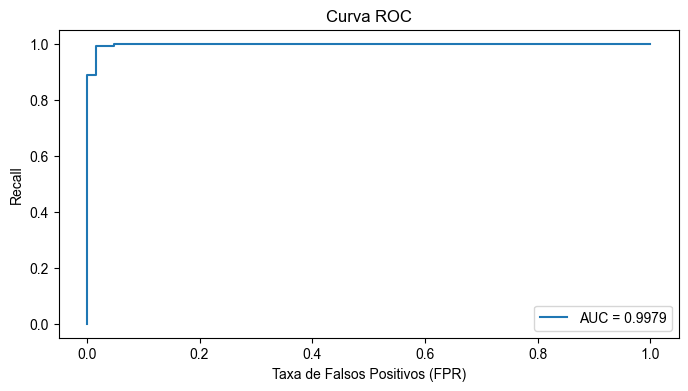

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")

# Plotar
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Recall')
plt.title('Curva ROC')
plt.legend()
plt.show()

---

## 4. Regularização e Validação Cruzada

O overfitting ocorre quando o modelo "decora" os dados de treino e não generaliza para novos dados. A regularização adiciona uma penalização à função de custo baseada na magnitude dos pesos. Na regularização Lasso (L1), a função de custo torna-se:

$$
J_{\textrm{reg}}(\theta) = J(\theta) + \alpha \sum_{i=1}^{p} |\theta_i|
$$

Na já regularização Ridge (L2), a função de custo é:

$$
J_{\textrm{reg}}(\theta) = J(\theta) + \frac{\alpha}{2} \sum_{i=1}^{p} \theta_i^2
$$

O parâmetro $\alpha$ controla a força da regularização. Um $\alpha$ muito alto pode causar underfitting (o modelo fica simples demais), enquanto um $\alpha$ muito baixo não resolve o *overfitting*. Uma dificuldade, no caso, seria a estimativa desse parâmetro $\alpha$. Para isso poderemos utilizar validação cruzada.

A validação cruzada é uma técnica para avaliar a capacidade de generalização de um modelo a partir de um conjunto de dados. O conceito central da validação cruzada é o particionamento do conjunto de dados em subconjuntos mutuamente exclusivos, e posteriormente, o uso de alguns destes subconjuntos para a estimação dos parâmetros do modelo (dados de treinamento), sendo os subconjuntos restantes (dados de validação) empregados na validação do modelo. Os dados de validação podem ser utilizados para estimar os melhores hiperparâmetros do modelo.

A variante mais comum de validação cruzada é a *K-Fold Cross-Validation*. O *dataset* é dividido em $k$ partes iguais (*folds*). O processo se repete $k$ vezes — a cada rodada, um *fold* diferente é usado como teste e os demais como treino:

```
Dataset:  [ F1 | F2 | F3 | F4 | F5 ]

Rodada 1: [TEST| tr | tr | tr | tr ]  → acc₁
Rodada 2: [ tr |TEST| tr | tr | tr ]  → acc₂
Rodada 3: [ tr | tr |TEST| tr | tr ]  → acc₃
Rodada 4: [ tr | tr | tr |TEST| tr ]  → acc₄
Rodada 5: [ tr | tr | tr | tr |TEST]  → acc₅

Resultado final: média(acc₁..acc₅) ± desvio_padrão
````

O resultado final é a média dos $k$ scores. O desvio padrão indica a estabilidade — um desvio alto significa que o modelo é sensível à forma como os dados são divididos.

A escolha de $k$ envolve um *trade-off*:

* $k$ pequeno (ex: 3): cada modelo treina com menos dados, estimativa menos precisa, mas mais rápido.
* $k$ grande (ex: 10): estimativa mais precisa, mas mais custoso computacionalmente.
* $k$ = 5 ou 10 são os valores mais usados na prática.

Um erro comum é usar a validação cruzada como substituta do conjunto de teste final. Os papéis são distintos:

* Validação Cruzada → usada DURANTE o desenvolvimento (comparar modelos, tunar hiperparâmetros);
* Conjunto de Teste  → usado APENAS no final (estimar performance real do modelo escolhido).

---

**Exemplo 4:** Vamos aplicar os conceitos de regularização e validação cruzada para o modelo de regressão linear do Exemplo 3.

Inicialmente vamos criar um dicionário com diversos parâmetros:

In [43]:
configs = [
    {'l1_ratio': 1, 'C': 0.01, 'solver': 'liblinear'}, #liblinear
    {'l1_ratio': 1, 'C': 0.1,  'solver': 'liblinear'},
    {'l1_ratio': 1, 'C': 1.0,  'solver': 'liblinear'},
    {'l1_ratio': 1, 'C': 10,   'solver': 'liblinear'},
    {'l1_ratio': 0, 'C': 0.01, 'solver': 'lbfgs'},
    {'l1_ratio': 0, 'C': 0.1,  'solver': 'lbfgs'},
    {'l1_ratio': 0, 'C': 1.0,  'solver': 'lbfgs'},
    {'l1_ratio': 0, 'C': 10,   'solver': 'lbfgs'},
]
# l1_ratio=0 --> Regularização L2
# l1_ratio=1 --> Regularização L1
# Obs: C = 1/a. Então valores altos de C indicam pouca regularização
# Grid Search

Agora vamos treinar um modelo de regressão logística com esses diversos parâmetros:

In [44]:
from sklearn.model_selection import cross_val_score
score_mean = np.zeros(len(configs))

for idx, cfg in enumerate(configs):
    m = LogisticRegression(max_iter=1000, random_state=42, **cfg)
    scores = cross_val_score(m, X_train_sc, y_train, cv=5)
    penalty_label = 'l1' if cfg['l1_ratio'] == 1 else 'l2'
    print(f"Penalidade = {penalty_label}, C = {cfg['C']:6} | "
          f"Acurácia: {scores.mean():.4f} ± {scores.std():.4f}")
    score_mean[idx] = scores.mean()

best_cfg = configs[np.argmax(score_mean)]
print(f"\nMelhor configuração = {best_cfg}")

Penalidade = l1, C =   0.01 | Acurácia: 0.9047 ± 0.0420
Penalidade = l1, C =    0.1 | Acurácia: 0.9648 ± 0.0094
Penalidade = l1, C =    1.0 | Acurácia: 0.9748 ± 0.0160
Penalidade = l1, C =     10 | Acurácia: 0.9773 ± 0.0168
Penalidade = l2, C =   0.01 | Acurácia: 0.9472 ± 0.0097
Penalidade = l2, C =    0.1 | Acurácia: 0.9723 ± 0.0096
Penalidade = l2, C =    1.0 | Acurácia: 0.9748 ± 0.0139
Penalidade = l2, C =     10 | Acurácia: 0.9722 ± 0.0218

Melhor configuração = {'l1_ratio': 1, 'C': 10, 'solver': 'liblinear'}


Após isso, vamos treinar o modelo com a melhor configuração:

In [45]:
# Treinar o modelo final com todos os dados de treino
best_model = LogisticRegression(max_iter=1000, random_state=42, **best_cfg)
best_model.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicla

E vamos avaliar para o conjunto de testes:

In [46]:
# Avaliar no conjunto de teste
y_pred = best_model.predict(X_test_sc)
y_prob = best_model.predict_proba(X_test_sc)[:, 1]

print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")

Acurácia: 0.9649
Precisão: 0.9904
Recall: 0.9537
F1-Score: 0.9717
AUC-ROC:  0.9928


---

## Exercícios

1. Por que a Regressão Logística é considerada um algoritmo de classificação, apesar do nome sugerir regressão? O que a função logística tem a ver com isso?
2. A função sigmoide mapeia qualquer valor real para o intervalo (0, 1). Explique como esse comportamento é explorado para estimar probabilidades e como a decisão de classe é tomada a partir dessas probabilidades.
3. Explique o *trade-off* entre Precisão e *Recall*. Em quais situações práticas você priorizaria cada uma dessas métricas? Dê um exemplo para cada caso.
4. O parâmetro $C$ do `LogisticRegression` do `sklearn` é definido como o inverso de $\alpha$. O que acontece com o modelo quando $C$ é muito alto? E quando $C$ é muito baixo?
5. Compare as regularizações L1 e L2 em termos de efeito sobre os coeficientes do modelo. Por que a regularização L1 tende a produzir coeficientes exatamente zero, enquanto a L2 apenas os reduz?
6. A acurácia é uma métrica suficiente para avaliar um classificador em todas as situações? Justifique com um exemplo onde ela pode ser enganosa e indique qual métrica seria mais adequada.
7. O que representa a AUC-ROC e qual é sua interpretação probabilística? O que significa um modelo com AUC = 0.5? E um com AUC = 1.0?
8. Explique o conceito de validação cruzada *K-Fold*. Por que ela produz uma estimativa mais confiável da performance do modelo do que uma única divisão treino/teste?
9. Qual é a diferença entre o conjunto de validação (usado na validação cruzada) e o conjunto de teste final? Por que é incorreto usar o score da validação cruzada como estimativa da performance final do modelo?